In [1]:
import numpy as np
import pandas as pd
import torch.nn as nn
import torch
import torch.optim as optim
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

In [37]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')

C:\Users\dhruv\AppData\Local\Temp\ipykernel_3640\2867026071.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [38]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468262,72.528582,71.223259,71.476600,135480400
2020-01-03,71.763725,72.523754,71.539337,71.696167,146322800
2020-01-06,72.335556,72.374162,70.634539,70.885472,118387200
2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000
2020-01-08,73.153496,73.455095,71.698581,71.698581,132079200
...,...,...,...,...,...
2025-12-31,271.859985,273.679993,271.750000,273.059998,27293600
2026-01-02,271.010010,277.839996,269.000000,272.260010,37838100


In [39]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [40]:
'''Choosing features, applying scaling'''
scaler_close = StandardScaler()
scaler_volume = StandardScaler()
df['Close'] = scaler_close.fit_transform(df['Close'])
df['Volume'] = scaler_volume.fit_transform(df['Volume'])
features = ['Close', 'Volume']

In [41]:
df['Close']

Ticker,AAPL
Date,
2020-01-02,-1.858361
2020-01-03,-1.872479
2020-01-06,-1.861020
2020-01-07,-1.867837
2020-01-08,-1.844630
...,...
2025-12-31,2.137185
2026-01-02,2.120153
2026-01-05,2.045008


In [53]:
train_len = 31
data = []

for i in range(len(df) - train_len):
    data.append(df[features][i:i+train_len])

data = np.array(data)

# Using TimeSeriesSplit since time is relevant here

tcsv = TimeSeriesSplit(n_splits=2, test_size = int(0.2 * len(data)))

train_idx, test_idx = list(tcsv.split(data))[-1]

X_train, X_test = torch.from_numpy(data[train_idx, :-1, :]).float(), torch.from_numpy(data[test_idx, :-1, :]).float()
y_train, y_test = torch.from_numpy(data[train_idx, -1, 0:1]).float(), torch.from_numpy(data[test_idx, -1, 0:1]).float()


In [54]:
y_train.shape

torch.Size([1185, 1])

In [55]:
class LSTMPredictionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMPredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        device = x.device
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])

        return out


In [56]:
# Replace input_dim with X_train.shape[2] for more modularity, keeps raising errors for equivalent values for unknown reasons
model = LSTMPredictionModel(input_dim = 2, hidden_dim = 64, num_layers = 2, output_dim=1)

In [57]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [58]:
epochs = 200

for i in range(epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)

    if (i % 25 == 0):
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


0 0.6363776922225952
25 0.01191643439233303
50 0.006085563916712999
75 0.006014321465045214
100 0.005237320903688669
125 0.005080697126686573
150 0.005018963944166899
175 0.004735980648547411


In [59]:
model.eval()

y_test_pred = model(X_test)
y_train_pred = scaler_close.inverse_transform(y_train_pred.detach().numpy())
y_train = scaler_close.inverse_transform(y_train.detach().numpy())
y_test_pred = scaler_close.inverse_transform(y_test_pred.detach().numpy())
y_test = scaler_close.inverse_transform(y_test.detach().numpy())

In [60]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [61]:
train_rmse

3.3207664489746094

In [62]:
test_rmse

10.932496070861816

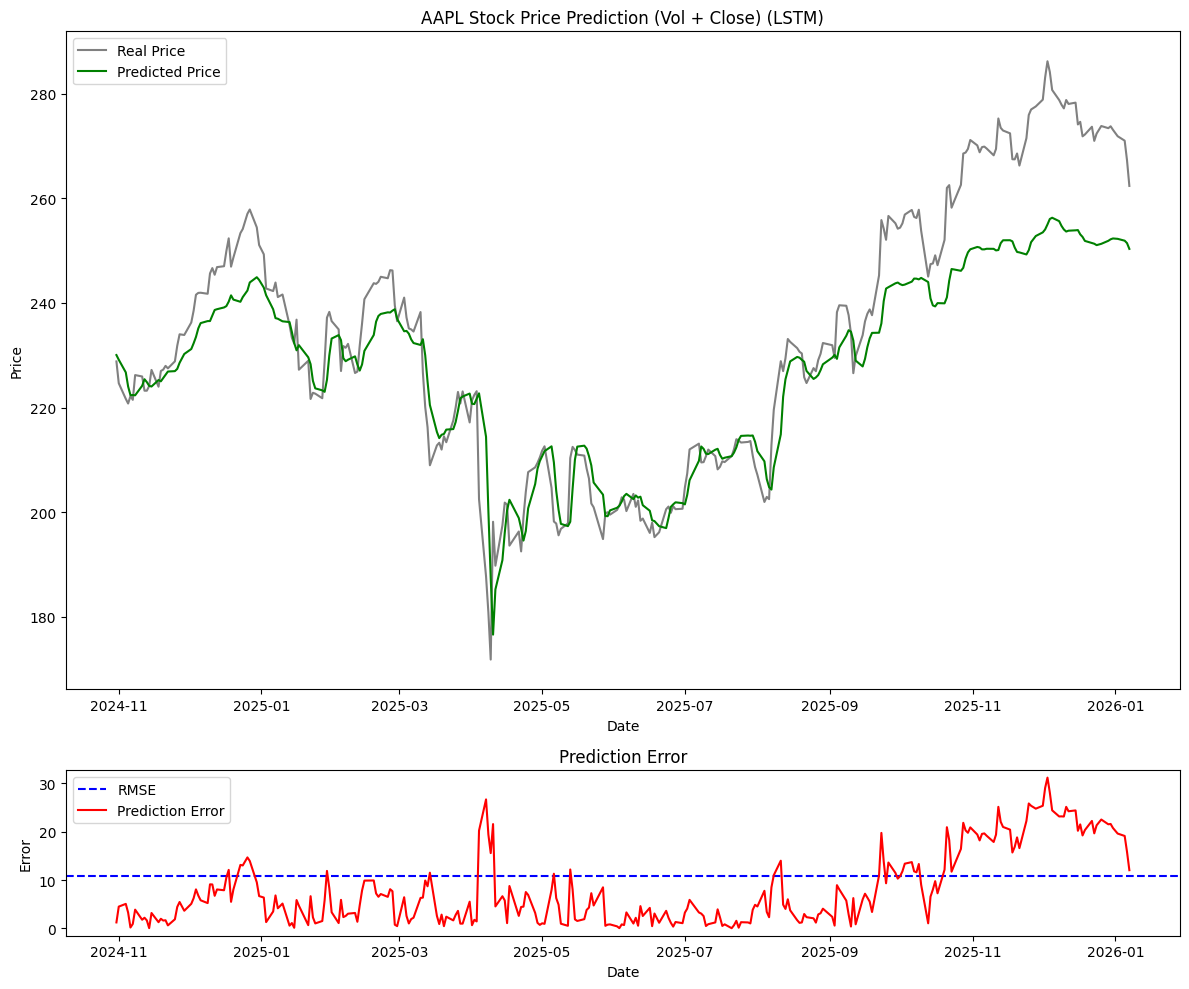

In [63]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test.ravel(), color = 'gray', label = 'Real Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred.ravel(), color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction (Vol + Close) (LSTM)")
plt.xlabel("Date")
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color = 'blue', linestyle = '--', label = 'RMSE')
ax2.plot(df.iloc[-len(y_test):].index, abs(y_test.ravel() - y_test_pred.ravel()), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()